In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [2]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Dataset extracted")

Dataset extracted


In [3]:
import os

print(os.listdir('dataset'))

['train', 'test']


In [4]:
!pip install tensorflow

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(48,48),
    batch_size=64,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.


In [8]:
test_generator = test_datagen.flow_from_directory(
    'dataset/test',
    target_size=(48,48),
    batch_size=64,
    class_mode='categorical'
)

Found 7178 images belonging to 7 classes.


In [9]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(48,48,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(7,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 115s 252ms/step - accuracy: 0.2921 - loss: 1.7371 - val_accuracy: 0.4068 - val_loss: 1.5259
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 116s 257ms/step - accuracy: 0.4161 - loss: 1.5020 - val_accuracy: 0.4500 - val_loss: 1.4215
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 112s 249ms/step - accuracy: 0.4709 - loss: 1.3794 - val_accuracy: 0.5098 - val_loss: 1.2892
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 113s 252ms/step - accuracy: 0.5067 - loss: 1.3024 - val_accuracy: 0.5191 - val_loss: 1.2726
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 112s 249ms/step - accuracy: 0.5278 - loss: 1.2450 - val_accuracy: 0.5350 - val_loss: 1.2081
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 113s 252ms/step - accuracy: 0.5505 - loss: 1.1944 - val_accuracy: 0.5450 - val_loss: 1.1961
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 112s 250ms/step - accuracy: 0.5699 - loss: 1.1424 - val_accuracy: 0.5578 - val_loss: 1.1689
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 114s 253ms/step - accuracy: 0.5826 -

In [12]:
loss, accuracy = model.evaluate(test_generator)

print("Accuracy:", accuracy)

113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.5620 - loss: 1.1855
Accuracy: 0.5619949698448181


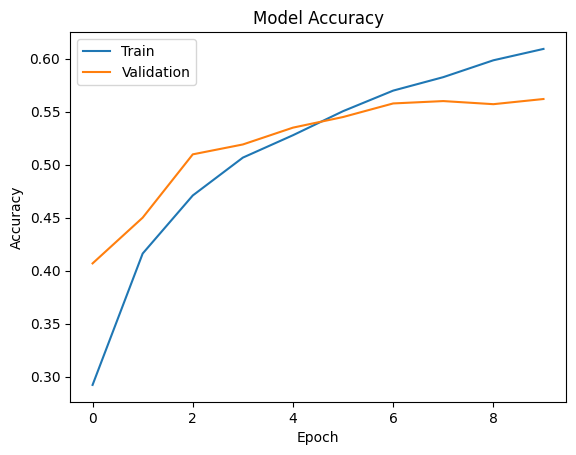

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

In [14]:
model.save("emotion_recognition_model.h5")

In [15]:
from google.colab import files

files.download("emotion_recognition_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>